In [1]:
import numpy as np

r = 0.1

def npv(n):
    return -1 + (n + 1) / (1 + r)**n

n_values = np.arange(1,31)
npv_values = npv(n_values)

max_index = np.argmax(npv_values)
optimal_n = n_values[max_index]
max_npv = npv_values[max_index]

print(optimal_n)
print(max_npv)

9
3.240976183724846


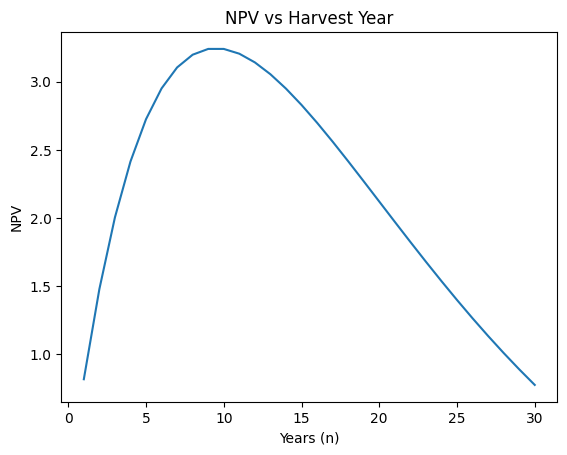

In [2]:
import matplotlib.pyplot as plt

plt.plot(n_values, npv_values)
plt.xlabel("Years (n)")
plt.ylabel("NPV")
plt.title("NPV vs Harvest Year")
plt.show()

In [6]:
(1+0.1/12)**12

1.1047130674412968

In [8]:
np.exp(0.1)

np.float64(1.1051709180756477)

In [9]:
import numpy as np

r = 0.10

monthly = (1 + r/12)**12
continuous = np.exp(r)

print("月次複利:", monthly)
print("連続複利:", continuous)

月次複利: 1.1047130674412968
連続複利: 1.1051709180756477


In [14]:
C = 500_000
r = 0.10
n = 20

t = np.arange(0,n)
cashflows = C / (1 + r)**t
print(t)
print(cashflows)
pv = np.sum(cashflows)

print(f"現在価値：{pv}")

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[500000.         454545.45454545 413223.14049587 375657.40045079
 341506.72768254 310460.66152958 282236.96502689 256579.05911535
 233253.69010487 212048.80918624 192771.64471477 175246.9497407
 159315.40885518 144832.18986834 131665.62715304 119696.02468458
 108814.56789507  98922.33445007  89929.39495461  81753.99541328]
現在価値：4682460.045867208


In [26]:
cashflows_a = np.array([-6000, -8000, -8000, -8000, -8000, 0])
cashflows_b = np.array([-30000,-2000, -2000, -2000, -2000, 10000])

def npv(cashflows, r):
    t = np.arange(len(cashflows))
    return np.sum(cashflows / (1 + r)**t)

print("PV A:", npv(cashflows_a, 0.12))
print("PV B:", npv(cashflows_b, 0.12))

PV A: -30298.79477301124
PV B: -30400.430136066818


In [27]:
def incremental_cashflows(cf_a, cf_b):
    return cf_b - cf_a

delta = incremental_cashflows(cashflows_a, cashflows_b)
pv_delta = npv(delta, 0.12)

print("PV incremental:", pv_delta)

PV incremental: -101.63536305558137


In [23]:
import nompy_financial as npf

ModuleNotFoundError: No module named 'nompy_financial'

In [24]:
import sys
!{sys.executable} -m pip install numpy-financial

In [25]:
import numpy_financial as npf

irr_delta = npf.irr(delta)
print("IRR (delta):", irr_delta)

IRR (delta): 0.11841015700240476


In [34]:
production = np.array([80000,70000,50000, 30000, 10000])
price = 20
net_income = np.array([1200000, 1000000, 500000, 200000, 50000])
tax_rate = 0.45
initial_investment = -1_000_000

gross_revenue = production * price

depletion1 = np.minimum(0.22 * gross_revenue, 0.5 * net_income)
depletion2 = 5 * production
depletion = np.maximum(depletion1, depletion2)

taxable_income = net_income - depletion
tax = taxable_income * tax_rate
after_tax_income = net_income - tax

cashflows = np.concatenate(([initial_investment], after_tax_income))
npv = npf.npv(0.20, cashflows)
irr = npf.irr(cashflows)

print(after_tax_income)
print(f"NPV(20%):{npv}")
print(f"IRR:{irr}")


[840000. 707500. 387500. 177500.  50000.]
NPV(20%):521260.9310699589
IRR:0.5279501228346601


In [ ]:
cashflows1 = array(-100, 30, 30, 30, 30, 30)
cashflows2 = array(-150, 42, 42, 42, 42, 42)

print(f"IRR1:{npf.irr(cashflow1